# BZU Student Intelligence Platform
### ENCS5342 — Natural Language Processing — Final Project Report

Bilingual (Arabic/English) text classification over a synthetic BZU student-community
corpus: **sentiment** (positive/negative/neutral) and **category**
(Course Feedback / Student Decisions / University Discussions), compared across five
models: Logistic Regression, Feed-Forward NN, LSTM, BiLSTM, and AraBERT.

This notebook imports directly from `src/` and only **runs and displays** the results
produced by that existing code — no model logic is redefined here.


In [1]:
import sys
from pathlib import Path

# Locate the project root (this notebook lives in notebooks/).
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
except ImportError:
    torch = None

print("Project root:", ROOT)


Project root: E:\Users\DEs\CE4.2\NLP\Project


## 1. Abstract

*(✍️ you write this — left intentionally empty.)*

- 
- 
- 


## 2. Introduction

*(✍️ you write this — left intentionally empty.)*

- Problem statement
- Motivation
- Contributions


## 3. Prior & Related Work

*(✍️ you write this — left intentionally empty.)*

- 
- 
- 


## 4. Model

Five classifiers are trained for **both** tasks (sentiment, category), all sharing the
same evaluation protocol (Section 6). Architectures and hyperparameters below are read
directly from the corresponding `src/models/*.py` modules.

| Model | Input representation | Architecture | Source |
|---|---|---|---|
| Logistic Regression | Shared TF‑IDF (1‑2 grams) over `clean_text` | `sklearn.linear_model.LogisticRegression` (`class_weight="balanced"`) | `src/models/logistic_regression.py` |
| Feed-Forward NN | Mean-pooled Skip-Gram Word2Vec document embedding | `Linear→ReLU→Dropout` × 2 → `Linear(num_classes)` | `src/models/neural_network.py` |
| LSTM | Own embedding layer + token sequence | `Embedding → LSTM → Dropout → Linear` | `src/models/lstm.py` |
| BiLSTM | Word2Vec-initialized embedding + token sequence | `Embedding(pretrained) → BiLSTM → Dropout → Linear`, early stopping, grad clipping, LR scheduler | `src/models/bilstm.py` |
| AraBERT (frozen) | Mean-pooled `aubmindlab/bert-base-arabertv02` hidden states (768-d) | Frozen encoder + the same Feed-Forward NN head | `src/models/arabert.py` |

All models are evaluated with a **group-aware** train/test split (Section 6) that holds
out whole template skeletons, in addition to a random split for Logistic Regression
(shown for contrast only).


In [2]:
# Hyperparameters pulled directly from src/ (factual, not re-derived).
import pandas as pd

from src.models.neural_network import HIDDEN_DIMS, DROPOUT as NN_DROPOUT, EPOCHS as NN_EPOCHS, LEARNING_RATE as NN_LR
from src.models.lstm import EMBED_DIM as LSTM_EMBED_DIM, HIDDEN_DIM as LSTM_HIDDEN, DROPOUT as LSTM_DROPOUT, EPOCHS as LSTM_EPOCHS
from src.models.bilstm import HIDDEN_DIM as BI_HIDDEN, DROPOUT as BI_DROPOUT, MAX_EPOCHS as BI_EPOCHS, EARLY_STOP_PATIENCE
from src.models.arabert import MODEL_NAME as ARABERT_MODEL_NAME, MAX_LEN as ARABERT_MAX_LEN
from src.features.tfidf import build_tfidf
import inspect

hparams = pd.DataFrame([
    {"model": "Logistic Regression", "key hyperparameters": "ngram_range=(1,2), min_df=2, max_df=0.9, class_weight=balanced"},
    {"model": "Feed-Forward NN", "key hyperparameters": f"hidden_dims={HIDDEN_DIMS}, dropout={NN_DROPOUT}, epochs={NN_EPOCHS}, lr={NN_LR}"},
    {"model": "LSTM", "key hyperparameters": f"embed_dim={LSTM_EMBED_DIM}, hidden_dim={LSTM_HIDDEN}, dropout={LSTM_DROPOUT}, epochs={LSTM_EPOCHS}"},
    {"model": "BiLSTM", "key hyperparameters": f"hidden_dim={BI_HIDDEN}, dropout={BI_DROPOUT}, max_epochs={BI_EPOCHS}, early_stop_patience={EARLY_STOP_PATIENCE}"},
    {"model": "AraBERT (frozen)", "key hyperparameters": f"encoder={ARABERT_MODEL_NAME}, max_len={ARABERT_MAX_LEN}, head=Feed-Forward NN"},
])
hparams


,model,key hyperparameters
0,Logistic Regression,"ngram_range=(1,2), min_df=2, max_df=0.9, class..."
1,Feed-Forward NN,"hidden_dims=(128, 64), dropout=0.3, epochs=120..."
2,LSTM,"embed_dim=100, hidden_dim=128, dropout=0.3, ep..."
3,BiLSTM,"hidden_dim=128, dropout=0.3, max_epochs=25, ea..."
4,AraBERT (frozen),"encoder=aubmindlab/bert-base-arabertv02, max_l..."


## 5. Data

A synthetic, template-generated bilingual (Arabic/English) corpus simulating BZU
student/community posts (course feedback, student movements & decisions, university
discussions), produced by `src/data/generate_dataset.py --seed 42` and cleaned by
`src/preprocessing/run_preprocessing.py`.


In [3]:
# Regenerate the raw + processed dataset from scratch so this notebook is fully
# self-contained and reproducible (same seed -> same data, every run).
# Note: generate_dataset.DEFAULT_OUT is a bare relative path (cwd-dependent), so we
# use run_preprocessing's ROOT-anchored DEFAULT_IN/DEFAULT_OUT for both, which are
# absolute and therefore safe regardless of this notebook's working directory.
from src.data.generate_dataset import generate, write_csv, DEFAULT_N
from src.preprocessing.run_preprocessing import preprocess_dataframe, DEFAULT_IN, DEFAULT_OUT
import pandas as pd

records = generate(DEFAULT_N, SEED)
write_csv(records, DEFAULT_IN)
print(f"Generated {len(records)} raw records -> {DEFAULT_IN}")

raw_df = pd.read_csv(DEFAULT_IN, encoding="utf-8-sig")
df, token_lists = preprocess_dataframe(raw_df)
df.to_csv(DEFAULT_OUT, index=False, encoding="utf-8-sig")
print(f"Wrote {len(df)} processed rows -> {DEFAULT_OUT}")
df.head()


Generated 4000 raw records -> E:\Users\DEs\CE4.2\NLP\Project\data\raw\bzu_dataset.csv


Wrote 4000 processed rows -> E:\Users\DEs\CE4.2\NLP\Project\data\processed\bzu_dataset_clean.csv


,id,language,category,course_name,professor_name,text,sentiment,date,clean_text,tokens,unigram_count,bigram_count,trigram_count
0,1,ar,Course Feedback,تفاضل وتكامل,لينا البرغوثي,لينا البرغوثي دكتور متعاون وبشرح تفاضل وتكامل ...,positive,2022-11-05,لينا البرغوثي دكتور متعاون وبشرح تفاضل وتكامل ...,لينا البرغوثي دكتور متعاون وبشرح تفاضل وتكامل ...,14,13,12
1,2,ar,Course Feedback,مترجمات,أحمد صالح,حبيت المشروع في مترجمات، كان صعب بس ممتعة والد...,positive,2025-03-08,حبيت المشروع في مترجمات كان صعب بس ممتعة والدك...,حبيت المشروع مترجمات صعب ممتعة والدكتور وجهنا ...,8,7,6
2,3,en,University Discussions,NaN,NaN,Honestly the the student clubs on campus is in...,positive,2023-03-18,honestly the the student clubs on campus is in...,honestly student clubs campus interesting now ...,9,8,7
3,4,en,University Discussions,NaN,NaN,the campus events at bzu is messy; something r...,negative,2026-02-18,the campus events at bzu is messy something re...,campus events bzu messy something needs change,7,6,5
4,5,en,Student Decisions,NaN,NaN,Students declared a strike over the class susp...,negative,2024-10-18,students declared a strike over the class susp...,students declared strike class suspensions wan...,9,8,7


In [4]:
# Dataset overview (factual statistics, no interpretation).
overview = pd.DataFrame({
    "language": df["language"].value_counts(),
}).rename_axis("value")
display(df["language"].value_counts().rename("count").to_frame())
display(df["sentiment"].value_counts().rename("count").to_frame())
display(df["category"].value_counts().rename("count").to_frame())
print(f"Total records: {len(df)}")
print(f"Avg tokens/record: {df['unigram_count'].mean():.2f}")


,count
language,
en,2096
ar,1904


,count
sentiment,
negative,1606
positive,1426
neutral,968


,count
category,
Course Feedback,2016
University Discussions,1121
Student Decisions,863


Total records: 4000
Avg tokens/record: 8.75


### Synthetic dataset — justification & limitations

*(✍️ you write this — left intentionally empty.)*

- 
- 
- 


## 6. Experiments

**Protocol** (identical for every model, reused from `src/models/logistic_regression.py`):

- **Group-aware split**: rows are grouped by *template skeleton* (`build_group_keys`),
  then `GroupShuffleSplit(test_size=0.2, random_state=42)` holds out whole templates —
  this is the realistic, leakage-free estimate.
- **Random split** (Logistic Regression only, shown for contrast): plain stratified
  `train_test_split`, which lets near-duplicate template rows leak between train/test
  and is therefore optimistic.
- A single global seed (`SEED = 42`, set above for `random`, `numpy`, and `torch`) is
  used throughout, so every model trains deterministically.

Each model is trained once on the group-train split; predictions are then taken on
**both** the train split and the held-out group-test split from that same fitted
model, so train-vs-validation metrics are directly comparable.


In [5]:
# Shared features: TF-IDF (LR) + Word2Vec embeddings (NN/LSTM/BiLSTM) + AraBERT (cached).
from src.models.logistic_regression import (
    SENTIMENT_LABELS, CATEGORY_LABELS, build_group_keys, prepare_features,
)
from src.features import embeddings as emb_mod

groups = build_group_keys(df)
vectorizer, X_tfidf = prepare_features(df)
y_sent = df["sentiment"].to_numpy()
y_cat = df["category"].to_numpy()

# Train (or load, if already cached) the Skip-Gram Word2Vec embeddings.
if emb_mod.VECTORS_FILE.exists():
    w2v = emb_mod.WordEmbeddings.load()
else:
    w2v = emb_mod.train_word2vec()
print(f"TF-IDF vocab: {len(vectorizer.vocabulary_)} | Word2Vec vocab: {len(w2v.itos)}")


Vocab size : 722
Pairs      : 115,652
Dim=100 window=2 neg=5 epochs=5


  epoch 1/5  loss=2.1540


  epoch 2/5  loss=0.8147


  epoch 3/5  loss=0.7001


  epoch 4/5  loss=0.6701


  epoch 5/5  loss=0.6534
Saved -> E:\Users\DEs\CE4.2\NLP\Project\models_store\embeddings\word2vec.npz
TF-IDF vocab: 3828 | Word2Vec vocab: 722


In [6]:
# Group-aware split (shared by all models for a fair, identical comparison).
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from src.models.logistic_regression import RANDOM_STATE, TEST_SIZE, _new_lr
from src.models.neural_network import group_aware_split, document_embeddings, train_model, predict_proba as nn_predict_proba
from src.models.lstm import token_lists_from_df, build_vocab as lstm_build_vocab, encode as lstm_encode, train_lstm, predict_proba as lstm_predict_proba
from src.models.bilstm import build_pretrained_matrix, train_bilstm, predict_proba as bilstm_predict_proba
from src.models.arabert import AraBERTEncoder, encode_corpus
from src.models.neural_network import train_model as nn_train_model
from src.evaluation.metrics import compute_metrics, get_classification_report
from src.evaluation.confusion_matrix import compute_confusion, save_confusion_plot

train_idx, test_idx = group_aware_split(groups)
print(f"docs={len(df)}  template_groups={len(set(groups))}  train={len(train_idx)}  test={len(test_idx)}")

REPORTS_DIR = ROOT / "reports"
token_lists_full = token_lists_from_df(df)
X_emb = document_embeddings(df, w2v)


docs=4000  template_groups=140  train=3065  test=935


In [7]:
# ----------------------------------------------------------------------- #
# Run every model once per task, collecting BOTH train-split and group-test
# predictions from the SAME fitted model (so the two splits are comparable).
# Every training/prediction call below is an existing, unmodified src/ function.
# ----------------------------------------------------------------------- #
results = {}  # results[(model, task)] = {"train": (y_true, y_pred), "test": (y_true, y_pred), "labels": [...]}

TASKS = [("sentiment", y_sent, SENTIMENT_LABELS), ("category", y_cat, CATEGORY_LABELS)]

# --- Logistic Regression (TF-IDF) --------------------------------------
for task_name, y, labels in TASKS:
    clf = _new_lr()
    clf.fit(X_tfidf[train_idx], y[train_idx])
    results[("Logistic Regression", task_name)] = {
        "train": (y[train_idx], clf.predict(X_tfidf[train_idx])),
        "test": (y[test_idx], clf.predict(X_tfidf[test_idx])),
        "labels": labels,
    }
print("Logistic Regression: done.")


Logistic Regression: done.


In [8]:
# --- Feed-Forward NN (Word2Vec document embeddings) --------------------
for task_name, y, labels in TASKS:
    model, mean, std = train_model(X_emb[train_idx], y[train_idx], labels)
    train_pred = np.array([labels[i] for i in nn_predict_proba(model, mean, std, X_emb[train_idx]).argmax(axis=1)])
    test_pred = np.array([labels[i] for i in nn_predict_proba(model, mean, std, X_emb[test_idx]).argmax(axis=1)])
    results[("Feed-Forward NN", task_name)] = {
        "train": (y[train_idx], train_pred),
        "test": (y[test_idx], test_pred),
        "labels": labels,
    }
print("Feed-Forward NN: done.")


Feed-Forward NN: done.


In [9]:
# --- LSTM (own embedding layer, vocab from train split only) -----------
for task_name, y, labels in TASKS:
    train_tokens = [token_lists_full[i] for i in train_idx]
    stoi = lstm_build_vocab(train_tokens)
    ids, lengths = lstm_encode(token_lists_full, stoi)
    model = train_lstm(ids[train_idx], lengths[train_idx], y[train_idx], len(stoi), labels)
    train_pred = np.array([labels[i] for i in lstm_predict_proba(model, ids[train_idx], lengths[train_idx]).argmax(axis=1)])
    test_pred = np.array([labels[i] for i in lstm_predict_proba(model, ids[test_idx], lengths[test_idx]).argmax(axis=1)])
    results[("LSTM", task_name)] = {
        "train": (y[train_idx], train_pred),
        "test": (y[test_idx], test_pred),
        "labels": labels,
    }
print("LSTM: done.")


LSTM: done.


In [10]:
# --- BiLSTM (pretrained Word2Vec init, early stopping) -----------------
for task_name, y, labels in TASKS:
    train_tokens = [token_lists_full[i] for i in train_idx]
    stoi = lstm_build_vocab(train_tokens)
    ids, lengths = lstm_encode(token_lists_full, stoi)
    pretrained, hits = build_pretrained_matrix(stoi, w2v)
    model, best_val_f1 = train_bilstm(ids[train_idx], lengths[train_idx], y[train_idx],
                                       groups[train_idx], len(stoi), labels, pretrained=pretrained)
    train_pred = np.array([labels[i] for i in bilstm_predict_proba(model, ids[train_idx], lengths[train_idx]).argmax(axis=1)])
    test_pred = np.array([labels[i] for i in bilstm_predict_proba(model, ids[test_idx], lengths[test_idx]).argmax(axis=1)])
    results[("BiLSTM", task_name)] = {
        "train": (y[train_idx], train_pred),
        "test": (y[test_idx], test_pred),
        "labels": labels,
    }
print(f"BiLSTM: done. (pretrained token coverage last task: {hits}/{len(stoi)}, best val macro-F1={best_val_f1:.4f})")


BiLSTM: done. (pretrained token coverage last task: 638/664, best val macro-F1=0.6617)


In [11]:
# --- AraBERT (frozen encoder + Feed-Forward NN head) --------------------
encoder = AraBERTEncoder()
X_bert = encode_corpus(df, encoder)
print(f"AraBERT embeddings: {X_bert.shape}")

for task_name, y, labels in TASKS:
    model, mean, std = nn_train_model(X_bert[train_idx], y[train_idx], labels)
    train_pred = np.array([labels[i] for i in nn_predict_proba(model, mean, std, X_bert[train_idx]).argmax(axis=1)])
    test_pred = np.array([labels[i] for i in nn_predict_proba(model, mean, std, X_bert[test_idx]).argmax(axis=1)])
    results[("AraBERT (frozen)", task_name)] = {
        "train": (y[train_idx], train_pred),
        "test": (y[test_idx], test_pred),
        "labels": labels,
    }
print("AraBERT: done.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded cached AraBERT embeddings (4000, 768) from E:\Users\DEs\CE4.2\NLP\Project\models_store\arabert\arabert_embeddings.npy
AraBERT embeddings: (4000, 768)


AraBERT: done.


In [12]:
# Logistic Regression random split (optimistic, shown for contrast only — Section 4 note).
random_split_results = {}
for task_name, y, labels in TASKS:
    Xtr, Xte, ytr, yte = train_test_split(X_tfidf, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    clf = _new_lr()
    clf.fit(Xtr, ytr)
    random_split_results[task_name] = {
        "train": (ytr, clf.predict(Xtr)),
        "test": (yte, clf.predict(Xte)),
        "labels": labels,
    }
print("Logistic Regression (random split, for contrast): done.")


Logistic Regression (random split, for contrast): done.


## 7. Results

For every model × task × split (train, group-aware test), the table below reports:
per-class precision/recall/F1, macro-averaged, micro-averaged (numerically equal to
accuracy for single-label multiclass classification), and overall accuracy — computed
with the project's own `src/evaluation/metrics.compute_metrics`.


In [13]:
def per_class_table(y_true, y_pred, labels):
    """Per-class P/R/F1 + macro/micro rows, via compute_metrics(average=...)."""
    per_class = compute_metrics(y_true, y_pred, labels=labels, average=None)
    rows = [
        {"class": lbl, "precision": p, "recall": r, "f1": f}
        for lbl, p, r, f in zip(labels, per_class["precision"], per_class["recall"], per_class["f1"])
    ]
    macro = compute_metrics(y_true, y_pred, labels=labels, average="macro")
    micro = compute_metrics(y_true, y_pred, labels=labels, average="micro")
    rows.append({"class": "macro avg", "precision": macro["precision"], "recall": macro["recall"], "f1": macro["f1"]})
    rows.append({"class": "micro avg", "precision": micro["precision"], "recall": micro["recall"], "f1": micro["f1"]})
    out = pd.DataFrame(rows).set_index("class").round(4)
    out.attrs["accuracy"] = macro["accuracy"]
    return out


def show_model_task(model_name, task_name):
    res = results[(model_name, task_name)]
    for split in ("train", "test"):
        y_true, y_pred = res[split]
        table = per_class_table(y_true, y_pred, res["labels"])
        split_label = "Train split" if split == "train" else "Group-aware test split"
        print(f"\n{model_name} — {task_name} — {split_label}  (accuracy={table.attrs['accuracy']:.4f}, n={len(y_true)})")
        display(table)


In [14]:
MODEL_NAMES = ["Logistic Regression", "Feed-Forward NN", "LSTM", "BiLSTM", "AraBERT (frozen)"]
for model_name in MODEL_NAMES:
    for task_name, _, _ in TASKS:
        show_model_task(model_name, task_name)



Logistic Regression — sentiment — Train split  (accuracy=1.0000, n=3065)


,precision,recall,f1
class,,,
positive,1.0,1.0,1.0
negative,1.0,1.0,1.0
neutral,1.0,1.0,1.0
macro avg,1.0,1.0,1.0
micro avg,1.0,1.0,1.0



Logistic Regression — sentiment — Group-aware test split  (accuracy=0.6866, n=935)


,precision,recall,f1
class,,,
positive,0.8996,0.7125,0.7952
negative,0.6042,0.8529,0.7073
neutral,0.6091,0.3237,0.4227
macro avg,0.7043,0.6297,0.6418
micro avg,0.6866,0.6866,0.6866



Logistic Regression — category — Train split  (accuracy=1.0000, n=3065)


...

,precision,recall,f1
class,,,
positive,0.6166,0.8165,0.7026
negative,0.8152,0.5611,0.6647
neutral,0.7522,0.8213,0.7852
macro avg,0.7280,0.7330,0.7175
micro avg,0.7080,0.7080,0.7080



AraBERT (frozen) — category — Train split  (accuracy=1.0000, n=3065)


,precision,recall,f1
class,,,
Course Feedback,1.0,1.0,1.0
Student Decisions,1.0,1.0,1.0
University Discussions,1.0,1.0,1.0
macro avg,1.0,1.0,1.0
micro avg,1.0,1.0,1.0



AraBERT (frozen) — category — Group-aware test split  (accuracy=0.8321, n=935)


,precision,recall,f1
class,,,
Course Feedback,0.9960,0.9860,0.9910
Student Decisions,0.4967,0.9933,0.6622
University Discussions,0.9712,0.4754,0.6383
macro avg,0.8213,0.8182,0.7638
micro avg,0.8321,0.8321,0.8321


In [15]:
# Logistic Regression random split, for contrast with the group-aware estimate above.
for task_name, _, _ in TASKS:
    res = random_split_results[task_name]
    for split in ("train", "test"):
        y_true, y_pred = res[split]
        table = per_class_table(y_true, y_pred, res["labels"])
        split_label = "Train split" if split == "train" else "Random test split (optimistic)"
        print(f"\nLogistic Regression (random split) — {task_name} — {split_label}  (accuracy={table.attrs['accuracy']:.4f}, n={len(y_true)})")
        display(table)



Logistic Regression (random split) — sentiment — Train split  (accuracy=1.0000, n=3200)


,precision,recall,f1
class,,,
positive,1.0,1.0,1.0
negative,1.0,1.0,1.0
neutral,1.0,1.0,1.0
macro avg,1.0,1.0,1.0
micro avg,1.0,1.0,1.0



Logistic Regression (random split) — sentiment — Random test split (optimistic)  (accuracy=1.0000, n=800)


,precision,recall,f1
class,,,
positive,1.0,1.0,1.0
negative,1.0,1.0,1.0
neutral,1.0,1.0,1.0
macro avg,1.0,1.0,1.0
micro avg,1.0,1.0,1.0



Logistic Regression (random split) — category — Train split  (accuracy=1.0000, n=3200)


,precision,recall,f1
class,,,
Course Feedback,1.0,1.0,1.0
Student Decisions,1.0,1.0,1.0
University Discussions,1.0,1.0,1.0
macro avg,1.0,1.0,1.0
micro avg,1.0,1.0,1.0



Logistic Regression (random split) — category — Random test split (optimistic)  (accuracy=1.0000, n=800)


,precision,recall,f1
class,,,
Course Feedback,1.0,1.0,1.0
Student Decisions,1.0,1.0,1.0
University Discussions,1.0,1.0,1.0
macro avg,1.0,1.0,1.0
micro avg,1.0,1.0,1.0


E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_sentiment.png


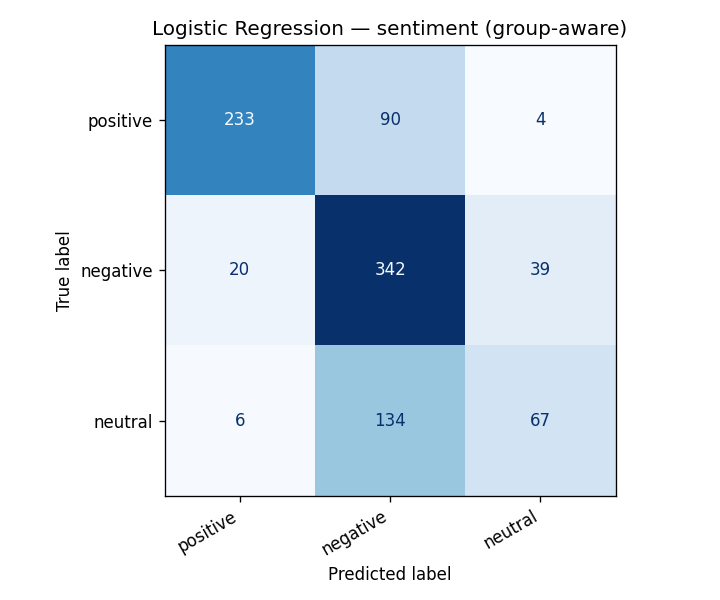

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_category.png


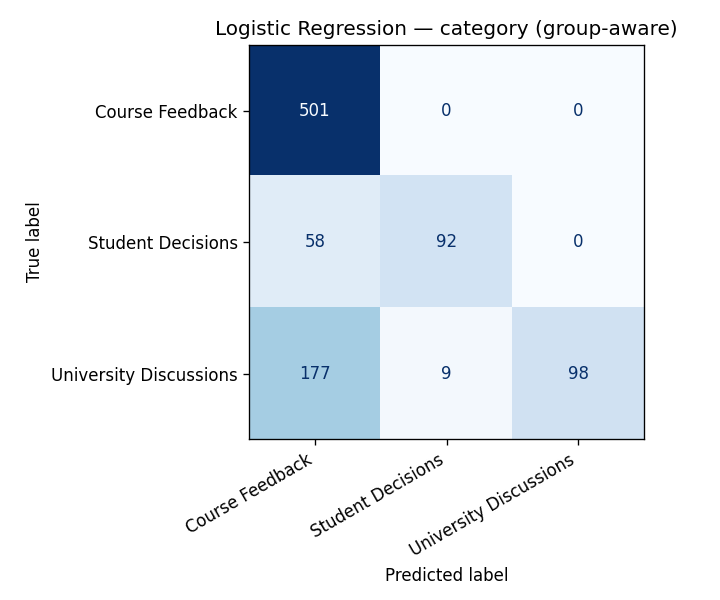

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_nn_sentiment.png


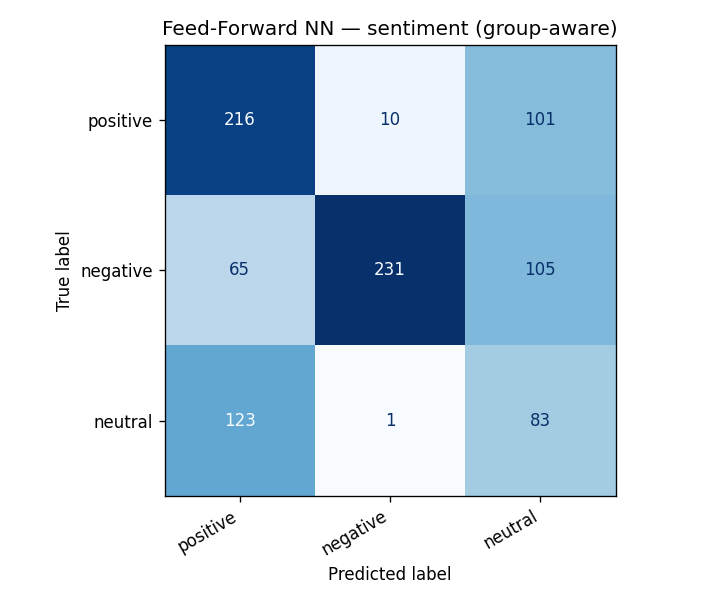

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_nn_category.png


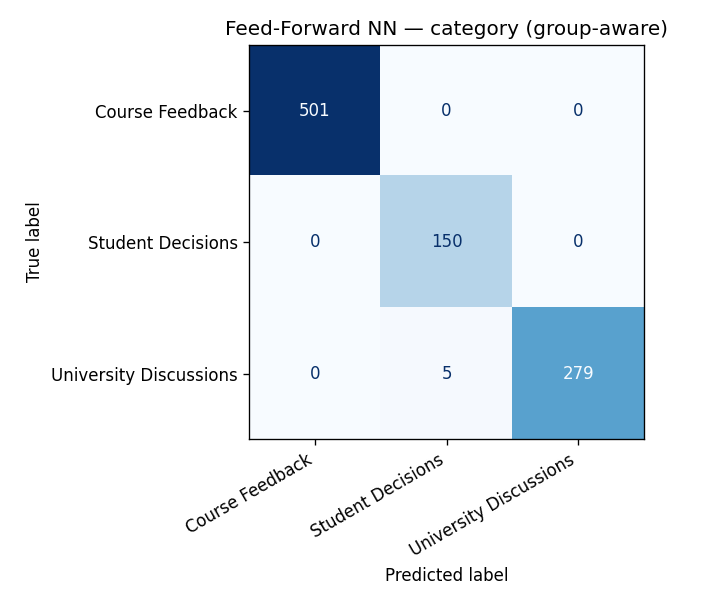

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_lstm_sentiment.png


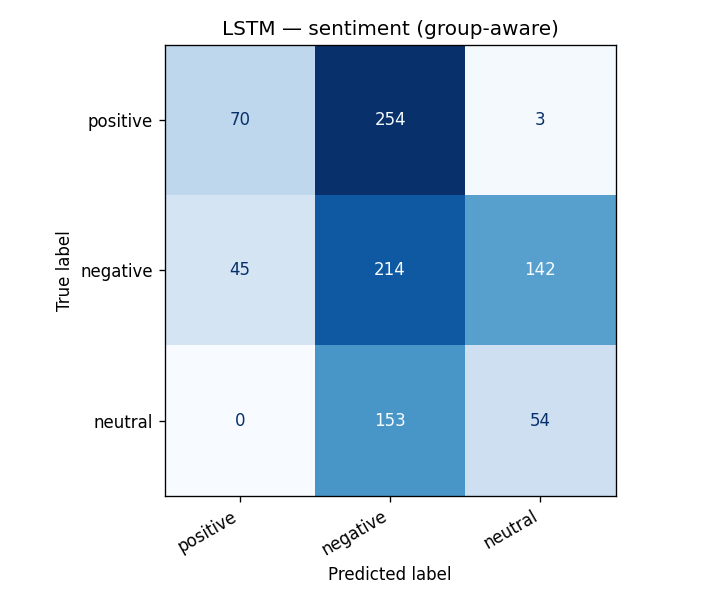

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_lstm_category.png


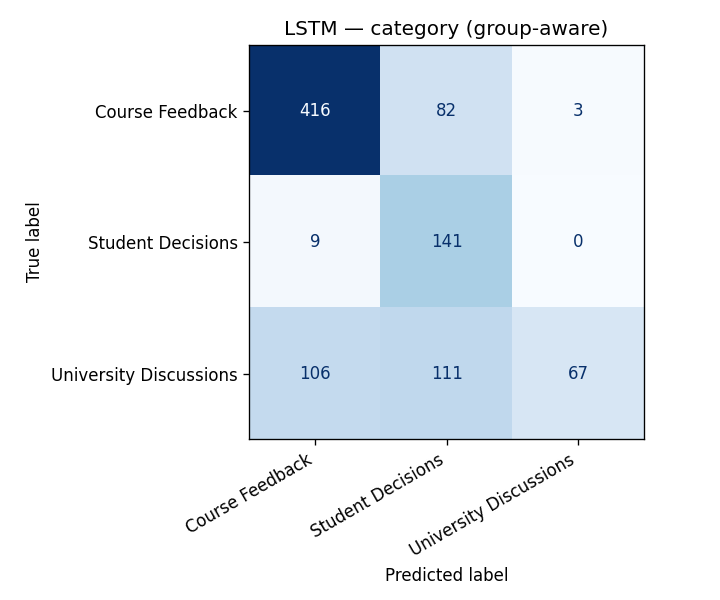

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_bilstm_sentiment.png


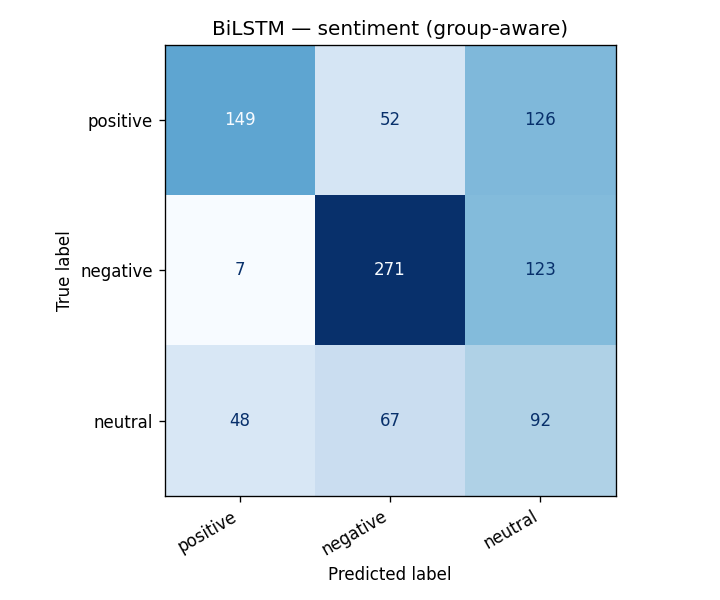

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_bilstm_category.png


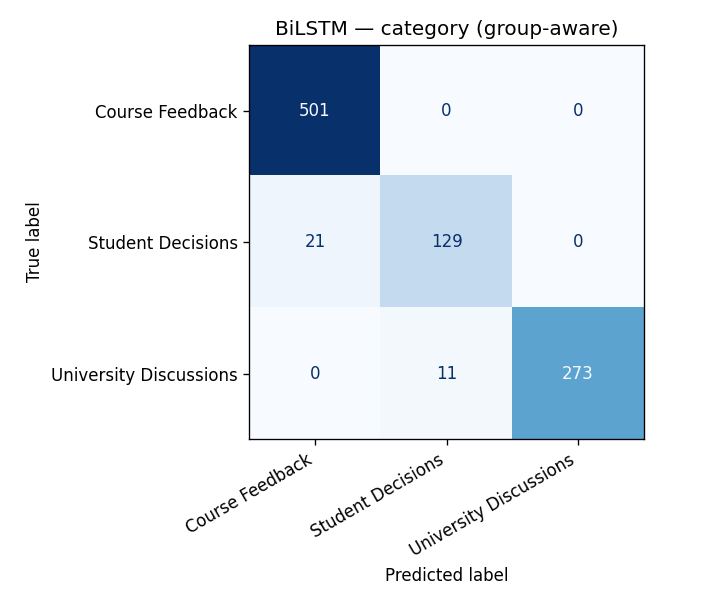

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_arabert_sentiment.png


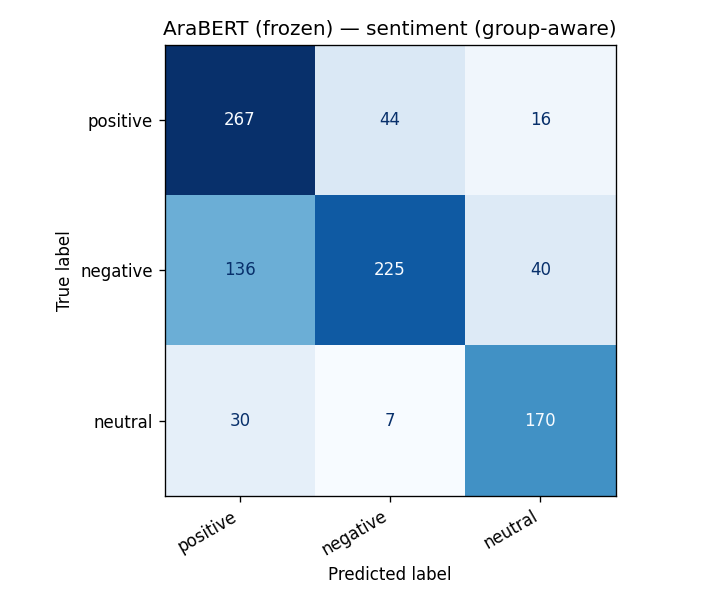

E:\Users\DEs\CE4.2\NLP\Project\reports\confusion_arabert_category.png


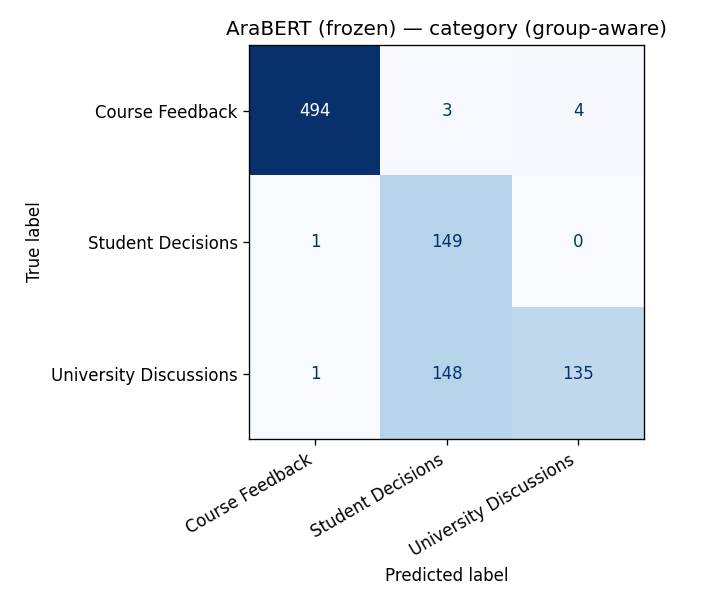

In [16]:
# Confusion matrices (group-aware test split) — regenerated fresh from this run
# and saved to reports/, via the project's own save_confusion_plot().
from IPython.display import Image, display as ipy_display

FIG_NAMES = {
    "Logistic Regression": ("confusion_sentiment.png", "confusion_category.png"),
    "Feed-Forward NN": ("confusion_nn_sentiment.png", "confusion_nn_category.png"),
    "LSTM": ("confusion_lstm_sentiment.png", "confusion_lstm_category.png"),
    "BiLSTM": ("confusion_bilstm_sentiment.png", "confusion_bilstm_category.png"),
    "AraBERT (frozen)": ("confusion_arabert_sentiment.png", "confusion_arabert_category.png"),
}

for model_name in MODEL_NAMES:
    for (task_name, _, labels), fig_name in zip(TASKS, FIG_NAMES[model_name]):
        y_true, y_pred = results[(model_name, task_name)]["test"]
        cm = compute_confusion(y_true, y_pred, labels)
        out_path = save_confusion_plot(cm, labels, f"{model_name} — {task_name} (group-aware)", REPORTS_DIR / fig_name)
        print(out_path)
        ipy_display(Image(filename=str(out_path)))


**Learning curves**: not shown. The current `train_model` / `train_lstm` /
`train_bilstm` functions in `src/models/` print the per-epoch loss to stdout when
`verbose=True` but do not return or persist it as data, so no per-epoch history is
available to plot without modifying that training code (out of scope here — see
the "do not rewrite model logic" constraint).


In [17]:
# Model comparison — group-aware test split, both tasks (facts only, no interpretation).
comparison_rows = []
for model_name in MODEL_NAMES:
    for task_name, _, labels in TASKS:
        y_true, y_pred = results[(model_name, task_name)]["test"]
        m = compute_metrics(y_true, y_pred, labels=labels, average="macro")
        comparison_rows.append({"model": model_name, "task": task_name,
                                "accuracy": m["accuracy"], "macro_f1": m["f1"]})
comparison_df = pd.DataFrame(comparison_rows).round(4)
display(comparison_df)

best = comparison_df.loc[comparison_df.groupby("task")["macro_f1"].idxmax()]
print("\nBest macro-F1 per task (group-aware split):")
display(best)


,model,task,accuracy,macro_f1
0,Logistic Regression,sentiment,0.6866,0.6418
1,Logistic Regression,category,0.7390,0.6854
2,Feed-Forward NN,sentiment,0.5668,0.5481
3,Feed-Forward NN,category,0.9947,0.9916
4,LSTM,sentiment,0.3615,0.3338
5,LSTM,category,0.6674,0.5891
6,BiLSTM,sentiment,0.5476,0.5274
7,BiLSTM,category,0.9658,0.9498
8,AraBERT (frozen),sentiment,0.7080,0.7175
9,AraBERT (frozen),category,0.8321,0.7638



Best macro-F1 per task (group-aware split):


,model,task,accuracy,macro_f1
3,Feed-Forward NN,category,0.9947,0.9916
8,AraBERT (frozen),sentiment,0.7080,0.7175


## 8. Analysis & Conclusion

*(✍️ you write this — left intentionally empty.)*

### Discussion
- 

### Limitations
- 

### Conclusion
- 


## 9. AI Usage Statement

*(✍️ you write this — left intentionally empty.)*

- 
- 
- 


## 10. References

*(✍️ you write this — left intentionally empty.)*

- 
